In [1]:
!pip install minigrid gymnasium matplotlib torch torchvision open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


In [2]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='openai'
)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model.eval()

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

Пространство действий: Discrete(7)
Всего действий: 7

Список действий в MiniGrid:
Номер: 0 -> Команда: left
Номер: 1 -> Команда: right
Номер: 2 -> Команда: forward
Номер: 3 -> Команда: pickup
Номер: 4 -> Команда: drop
Номер: 5 -> Команда: toggle
Номер: 6 -> Команда: done
Размерность кадра среды: (256, 256, 3)


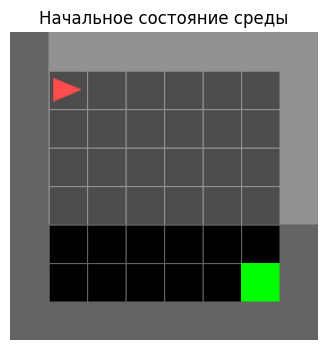

Случайный эпизод завершен за 50 шагов. Награда: 0


In [3]:
import gymnasium as gym
import minigrid
from minigrid.wrappers import ImgObsWrapper
import random
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")

print(f"Пространство действий: {env.action_space}")
print(f"Всего действий: {env.action_space.n}")

print("\nСписок действий в MiniGrid:")
for action in env.unwrapped.actions:
    print(f"Номер: {action.value} -> Команда: {action.name}")

obs, info = env.reset(seed=42)

frame = env.render()
print(f"Размерность кадра среды: {frame.shape}")

# Показываем начальный кадр
plt.figure(figsize=(4, 4))
plt.imshow(frame)
plt.title("Начальное состояние среды")
plt.axis('off')
plt.show()

# Демонстрация одного случайного эпизода
steps, total_reward, done = 0, 0, False
while not done and steps < 50:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    # plt.imshow(frame)
    # plt.axis('off')
    # plt.show()
    done = terminated or truncated
    total_reward += reward
    steps += 1

print(f"Случайный эпизод завершен за {steps} шагов. Награда: {total_reward}")
env.close()

In [4]:
env = gym.make("MiniGrid-Empty-8x8-v0")

obs, info = env.reset()

u = env.unwrapped

print(type(u))

print("agent_pos:", hasattr(u, "agent_pos"))
print("agent_dir:", hasattr(u, "agent_dir"))

print("goal_pos:", hasattr(u, "goal_pos"))
grid_matrix = np.array(env.unwrapped.grid.encode())[:, :, 0]
print(grid_matrix)
print(dir(u)[:50])

GOAL_OBJECT_ID = 8

# Получаем матрицу типов объектов (размерность Width x Height)
grid_matrix = np.array(env.unwrapped.grid.encode())[:, :, 0]

# Ищем индексы, где ID равен 8
positions = np.argwhere(grid_matrix == GOAL_OBJECT_ID)

if len(positions) > 0:
    goal_pos = tuple(positions[0]) # Извлекаем первую найденную цель
    print("Координаты цели через numpy:", goal_pos)
else:
    print("Цель на карте не найдена")
print(env.unwrapped.grid.get(*goal_pos).type) # Должно напечатать: goal

<class 'minigrid.envs.empty.EmptyEnv'>
agent_pos: True
agent_dir: True
goal_pos: False
[[2 2 2 2 2 2 2 2]
 [2 1 1 1 1 1 1 2]
 [2 1 1 1 1 1 1 2]
 [2 1 1 1 1 1 1 2]
 [2 1 1 1 1 1 1 2]
 [2 1 1 1 1 1 1 2]
 [2 1 1 1 1 1 8 2]
 [2 2 2 2 2 2 2 2]]
['__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_gen_grid', '_gen_mission', '_np_random', '_np_random_seed', '_rand_bool', '_rand_color', '_rand_elem', '_rand_float', '_rand_int', '_rand_pos', '_rand_subset', '_reward', 'action_space', 'actions', 'agent_dir', 'agent_pos', 'agent_pov']
Координаты цели через numpy: (np.int64(6), np.int64(6))
goa

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Энкодер: картинка -> вектор признаков
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=4, stride=2, padding=1), # -> 16 x 32 x 32
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), # -> 32 x 16 x 16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # -> 64 x 8 x 8
            nn.ReLU(),
            nn.Flatten() # -> 64 * 8 * 8 = 4096
        )
        self.fc = nn.Linear(4096, 256)

    def forward(self, x):
        # x: [batch, 3, 64, 64]
        return self.fc(self.net(x))


# 2. Декодер: скрытое состояние (h + z) -> воображаемая картинка
class Decoder(nn.Module):
    def __init__(self, h_dim=128, z_dim=256):
        super().__init__()
        self.fc = nn.Linear(h_dim + z_dim, 4096)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # -> 32 x 16 x 16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # -> 16 x 32 x 32
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1),  # -> 6 x 64 x 64
            nn.Sigmoid() # Пиксели от 0 до 1
        )

    def forward(self, h, z):
        # h: [batch, h_dim], z: [batch, z_dim]
        x = torch.cat([h, z], dim=-1)
        x = F.relu(self.fc(x)).view(-1, 64, 8, 8)
        return self.net(x)

# # 3. Ядро RSSM
# class RSSM(nn.Module):
#     def __init__(self, action_dim=7, h_dim=128, z_dim=32):
#         super().__init__()
#         self.z_dim = z_dim

#         # Слой для объединения прошлого z и прошлого действия перед GRU
#         self.input_embed = nn.Linear(z_dim + action_dim, 128)
#         self.gru = nn.GRUCell(128, h_dim)

#         # Сеть переходов (Prior) - предсказание будущего вслепую
#         self.prior_net = nn.Linear(h_dim, z_dim * 2) # Выдаёт mu и log_sigma

#         # Сеть представлений (Posterior) - коррекция по реальной картинке
#         self.post_net = nn.Linear(h_dim + 256, z_dim * 2)

#     def init_state(self, batch_size=1, device='cpu'):
#         return (torch.zeros(batch_size, 128, device=device),
#                 torch.zeros(batch_size, self.z_dim, device=device))

#     def reparameterize(self, mu, log_sigma):
#         sigma = torch.exp(log_sigma)
#         eps = torch.randn_like(sigma)
#         return mu + eps * sigma

#     def get_prior(self, h):
#         out = self.prior_net(h)
#         mu, log_sigma = torch.chunk(out, 2, dim=-1)
#         log_sigma = torch.clamp(log_sigma, -5, 2) # Защита от взрыва градиентов
#         z = self.reparameterize(mu, log_sigma)
#         return z, mu, log_sigma

#     def get_posterior(self, h, embed):
#         out = self.post_net(torch.cat([h, embed], dim=-1))
#         mu, log_sigma = torch.chunk(out, 2, dim=-1)
#         log_sigma = torch.clamp(log_sigma, -5, 2)
#         z = self.reparameterize(mu, log_sigma)
#         return z, mu, log_sigma

#     def observe_step(self, prev_h, prev_z, action, embed):
#         """Один шаг во время обучения (с реальным фото)"""
#         # action должен быть в формате One-Hot вектора размера [batch, 7]
#         inputs = F.relu(self.input_embed(torch.cat([prev_z, action], dim=-1)))
#         h = self.gru(inputs, prev_h)
#         z, mu, log_sigma = self.get_posterior(h, embed)
#         return h, z, mu, log_sigma

#     def imagine_step(self, prev_h, prev_z, action):
#         """Один шаг воображения во время инференса/планирования (БЕЗ фото)"""
#         inputs = F.relu(self.input_embed(torch.cat([prev_z, action], dim=-1)))
#         h = self.gru(inputs, prev_h)
#         z, mu, log_sigma = self.get_prior(h)
#         return h, z, mu, log_sigma

# 3. Дискретное Ядро RSSM (16x16)
class RSSM(nn.Module):
    def __init__(self, action_dim=7, h_dim=128, num_categories=16, num_classes=16):
        super().__init__()
        self.num_categories = num_categories
        self.num_classes = num_classes
        self.z_dim = num_categories * num_classes # 256

        # Слой для объединения прошлого z и прошлого действия перед GRU
        self.input_embed = nn.Linear(self.z_dim + action_dim, 128)
        self.gru = nn.GRUCell(128, h_dim)

        # Сеть переходов (Prior) - предсказание будущего (теперь выдает логиты)
        self.prior_net = nn.Linear(h_dim, self.z_dim)

        # Сеть представлений (Posterior) - коррекция по реальной картинке
        self.post_net = nn.Linear(h_dim + 256, self.z_dim)

    def init_state(self, batch_size=1, device='cpu'):
        return (torch.zeros(batch_size, 128, device=device),
                torch.zeros(batch_size, self.z_dim, device=device))

    def sample_z(self, logits, temperature=1.0):
        # Преобразуем плоский вектор в матрицу [Batch, 16, 16]
        shape = logits.shape[:-1]
        logits = logits.view(*shape, self.num_categories, self.num_classes)

        # Gumbel-Softmax trick (hard=True делает вектор дискретным)
        z = F.gumbel_softmax(logits, tau=temperature, hard=True, dim=-1)

        # Возвращаем обратно в плоский вид [Batch, 256] для декодера и RNN
        return z.view(*shape, self.z_dim)

    def get_prior(self, h):
        prior_logits = self.prior_net(h)
        z_prior = self.sample_z(prior_logits)
        return z_prior, prior_logits

    def get_posterior(self, h, embed):
        post_logits = self.post_net(torch.cat([h, embed], dim=-1))
        z_post = self.sample_z(post_logits)
        return z_post, post_logits

    def observe_step(self, prev_h, prev_z, action, embed):
        """Один шаг во время обучения (с реальным фото)"""
        inputs = F.relu(self.input_embed(torch.cat([prev_z, action], dim=-1)))
        h = self.gru(inputs, prev_h)
        z, post_logits = self.get_posterior(h, embed)
        return h, z, post_logits

    def imagine_step(self, prev_h, prev_z, action):
        """Один шаг воображения во время инференса/планирования (БЕЗ фото)"""
        inputs = F.relu(self.input_embed(torch.cat([prev_z, action], dim=-1)))
        h = self.gru(inputs, prev_h)
        z, prior_logits = self.get_prior(h)
        return h, z, prior_logits

In [6]:
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from collections import deque

# Функция для сжатия кадра MiniGrid (из 256x256 в 64x64) и превращения в тензор
def preprocess_frame(frame):
    # frame: numpy array [256, 256, 3]
    tensor_frame = torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0 # -> [3, 256, 256]
    resize = T.Resize((64, 64))
    return resize(tensor_frame)

class SequenceReplayBuffer:
    def __init__(self, capacity=500):
        self.capacity = capacity
        self.episodes = deque(maxlen=capacity)

    def push_episode(self, frames, actions, vlm_scores, positions, success):
        self.episodes.append((frames, actions, vlm_scores, positions, success)) # ADDED pos

    def __len__(self):
        return len(self.episodes)

    def sample_batch(self, batch_size=32, seq_len=12):
        """Сэмплирует батч последовательных кусочков траекторий"""
        batch_frames = []
        batch_actions = []
        batch_vlm_scores = []
        batch_pos = [] # ADDED

        while len(batch_frames) < batch_size:
            episode = random.choice(self.episodes)
            ep_frames, ep_actions, ep_scores, ep_positions, ep_success = episode # ADDED pos
            if len(ep_actions) < seq_len:
                continue

            max_start = len(ep_actions) - seq_len
            if ep_success and random.random() < 0.5:
                start_idx = max(0, len(ep_actions) - seq_len - random.randint(0, 5))
            else:
                start_idx = random.randint(0, max_start)

            sub_frames = ep_frames[start_idx : start_idx + seq_len + 1]
            sub_actions = ep_actions[start_idx : start_idx + seq_len]
            sub_scores = ep_scores[start_idx : start_idx + seq_len + 1]
            sub_pos = ep_positions[start_idx : start_idx + seq_len + 1] # ADDED

            # Переводим действия в One-Hot формат (размерность 7)
            one_hot_actions = F.one_hot(
                torch.tensor(sub_actions),
                num_classes=7
            ).float()

            batch_frames.append(torch.stack(sub_frames)) # [seq_len + 1, 3, 64, 64]
            batch_actions.append(one_hot_actions)        # [seq_len, 7]
            batch_vlm_scores.append(torch.tensor(sub_scores).float())
            batch_pos.append(torch.tensor(sub_pos).float()) # [seq_len + 1, 2]

        # Склеиваем в итоговые батчи для PyTorch
        # Размеры на выходе: [Batch, Seq_Len, ...]
        return (
            torch.stack(batch_frames),
            torch.stack(batch_actions),
            torch.stack(batch_vlm_scores),
            torch.stack(batch_pos) # ADDED
        )

In [7]:
class AgentPosHead(nn.Module):
    def __init__(self, h_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(h_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # Предсказываем [x, y] координаты (например, нормализованные от -1 до 1)
        )

    def forward(self, h):
        return self.net(h)

# Инициализируй её вместе с остальными компонентами:
# pos_head = AgentPosHead().to(device)

In [8]:
def categorical_kl_loss(post_logits, prior_logits, alpha=0.8, num_categories=16, num_classes=16):
    """Сбалансированная KL-дивергенция для матрицы 16x16"""
    batch_size = post_logits.shape[0]
    post_logits = post_logits.view(batch_size, num_categories, num_classes)
    prior_logits = prior_logits.view(batch_size, num_categories, num_classes)

    post_probs = torch.softmax(post_logits, dim=-1)
    post_log_probs = torch.log_softmax(post_logits, dim=-1)
    prior_log_probs = torch.log_softmax(prior_logits, dim=-1)

    def kl_div(p_probs, p_log_probs, q_log_probs):
        kl = (p_probs * (p_log_probs - q_log_probs)).sum(dim=-1)
        return kl.mean()

    value_loss = kl_div(post_probs.detach(), post_log_probs.detach(), prior_log_probs)
    prior_loss = kl_div(post_probs, post_log_probs, prior_log_probs.detach())

    return alpha * value_loss + (1.0 - alpha) * prior_loss

def train_world_model_step(encoder, decoder, rssm, vlm_model, pos_head, batch_frames, batch_actions, batch_vlm_scores, batch_pos, optimizer): # ADDED pos
    # batch_frames: [B, L+1, 3, 64, 64]
    # batch_actions: [B, L, 7]
    device = next(rssm.parameters()).device
    batch_frames = batch_frames.to(device)
    batch_actions = batch_actions.to(device)
    batch_vlm_scores = batch_vlm_scores.to(device)
    batch_pos = batch_pos.to(device) # ADDED

    b, l, _ = batch_actions.shape

    # 1. Инициализируем стартовое состояние памяти нулями
    h, z = rssm.init_state(batch_size=b, device=device)

    recon_loss = 0
    kl_loss = 0
    vlm_loss = 0
    pos_loss = 0 # ADDED

    optimizer.zero_grad()

    # Прогоняем цепочку по времени вперед (от 0 до L-1)
    for t in range(l):
        # Реальный кадр в момент t+1, который мы должны научиться предсказывать
        target_frame = batch_frames[:, t+1]
        target_score = batch_vlm_scores[:, t + 1]
        target_pos = batch_pos[:, t + 1] # ADDED

        # Прогоняем его через энкодер
        embed = encoder(target_frame)
        # Делаем шаг observe_step -> получаем Posterior логиты
        prev_h, prev_z = h, z

        # ИСПРАВЛЕНИЕ 1: observe_step теперь возвращает 3 значения (h, z, post_logits)
        h, z, post_logits = rssm.observe_step(prev_h, prev_z, batch_actions[:, t], embed)

        # ИСПРАВЛЕНИЕ 2: get_prior возвращает 2 значения и должен принимать текущий h
        _, prior_logits = rssm.get_prior(h)

        # А теперь заставляем Декодер восстановить картинку из латентного состояния z
        recon_frame = decoder(h, z)

        # 1-й Лосс: Ошибка реконструкции (BCE или MSE между оригиналом и тем, что нарисовал Декодер)
        recon_loss += F.mse_loss(recon_frame, target_frame, reduction='sum')
        # target_pos - это реальные координаты агента [B, 2] из среды, нормализованные в [0, 1]

        # 2-й Лосс: VLM-оценка
        pred_score = vlm_model(h, z).squeeze(-1)
        vlm_loss += F.mse_loss(pred_score, target_score)
        # 3-й Лосс: оценка позиции
        pred_pos = pos_head(h) # ADDED
        pos_loss += F.mse_loss(pred_pos, target_pos, reduction='sum') # ADDED
        # 4. KL Balancing: Передаем логиты в функцию расчета KL-лосса  (дискретный)
        kl_loss += categorical_kl_loss(post_logits, prior_logits, alpha=0.8, num_categories=16, num_classes=16)


# def train_world_model_step(encoder, decoder, rssm, vlm_model, batch_frames, batch_actions, batch_vlm_scores, optimizer):
#     # batch_frames: [B, L+1, 3, 64, 64]
#     # batch_actions: [B, L, 7]
#     device = next(rssm.parameters()).device
#     batch_frames = batch_frames.to(device)
#     batch_actions = batch_actions.to(device)
#     batch_vlm_scores = batch_vlm_scores.to(device)

#     b, l, _ = batch_actions.shape

#     # 1. Инициализируем стартовое состояние памяти нулями
#     h, z = rssm.init_state(batch_size=b, device=device)

#     recon_loss = 0
#     kl_loss = 0
#     vlm_loss = 0

#     optimizer.zero_grad()

#     # Прогоняем цепочку по времени вперед (от 0 до L-1)
#     for t in range(l):
#         # Реальный кадр в момент t+1, который мы должны научиться предсказывать
#         target_frame = batch_frames[:, t+1]
#         target_score = batch_vlm_scores[:, t + 1]

#         # Прогоняем его через энкодер
#         embed = encoder(target_frame)

#         # Делаем шаг observe_step -> получаем Posterior распределение
#         # (Оно знает, какое действие совершили, и видит реальный кадр t+1)
#         prev_h, prev_z = h, z
#         h, z, post_mu, post_log_sigma = rssm.observe_step(prev_h, prev_z, batch_actions[:, t], embed)
#         # Считаем Prior распределение БЕЗ картинки (чисто интуиция модели из старой памяти)
#         # Corrected unpacking: rssm.get_prior returns 3 values (z, mu, log_sigma)
#         _, prior_mu, prior_log_sigma = rssm.get_prior(prev_h)
#         # А теперь заставляем Декодер восстановить картинку из латентного состояния z
#         recon_frame = decoder(h, z)

#         # 1-й Лосс: Ошибка реконструкции (MSE между оригиналом и тем, что нарисовал Декодер)
#         recon_loss += F.binary_cross_entropy(recon_frame, target_frame, reduction='sum')

#         pred_score = vlm_model(h, z).squeeze(-1)
#         vlm_loss += F.mse_loss(pred_score, target_score)

        # 2-й Лосс: KL-дивергенция (сближаем Prior и Posterior)
        # post_dist = torch.distributions.Normal(post_mu, torch.exp(post_log_sigma))
        # prior_dist = torch.distributions.Normal(prior_mu, torch.exp(prior_log_sigma))

        # # Считаем расстояние между распределениями
        # # kl = torch.distributions.kl.kl_divergence(post_dist, prior_dist).sum(dim=-1).mean()
        # # kl_loss += kl
        # # kl_prior: обучаем ТОЛЬКО prior (динамику), подтягивая его к зафиксированному posterior
        # kl_prior = (
        #     torch.distributions.kl.kl_divergence(
        #         torch.distributions.Normal(post_mu.detach(), torch.exp(post_log_sigma).detach()), prior_dist
        #     )
        #     .sum(dim=-1)
        #     .mean()
        # )

        # # kl_post: обучаем ТОЛЬКО posterior (энкодер), не давая ему уходить далеко от зафиксированного prior
        # kl_post = (
        #     torch.distributions.kl.kl_divergence(
        #         post_dist, torch.distributions.Normal(prior_mu.detach(), torch.exp(prior_log_sigma).detach())
        #     )
        #     .sum(dim=-1)
        #     .mean()
        # )

        # # Балансируем веса: приоритет обучению динамики (0.8)
        # kl_loss += 0.8 * kl_prior + 0.2 * kl_post

    # Усредняем по размеру батча и длине последовательности
    recon_loss = recon_loss / (b * l)
    kl_loss = kl_loss / (b * l)
    vlm_loss = vlm_loss / (b * l)
    pos_loss /= (b * l) # ADDED

    # Итоговый лосс с коэффициентом бета (обычно бета = 0.1 - 1.0, чтобы KL не задушил реконструкцию)
    beta = 1
    gamma = 1
    total_loss = 0.7 * recon_loss + beta * kl_loss + gamma * vlm_loss + 10.0 * pos_loss # ADDED pos

    # Шаг оптимизатора
    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        list(encoder.parameters())
        + list(decoder.parameters())
        + list(rssm.parameters())
        + list(vlm_model.parameters())
        + list(pos_head.parameters()), # Corrected concatenation
        100.0
    )

    # total_norm = 0

    # for p in rssm.parameters():
    #     if p.grad is not None:
    #         total_norm += p.grad.norm().item() ** 2

    # print(np.sqrt(total_norm))

    optimizer.step()

    return total_loss.item(), recon_loss.item(), kl_loss.item(), vlm_loss.item(), pos_loss.item()


In [9]:
# 4. Модель награды (Reward Model) - предсказывает награду на следующем шаге
# Это важная часть DreamerV2.
# Она берет скрытое состояние (h и z) и предсказывает награду.
# Обычно это простая многослойная перцептронная сеть (MLP).
class VLMScoreModel(nn.Module):
    def __init__(self, h_dim=128, z_dim=256, hidden_size=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(h_dim + z_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1) # Предсказываем скалярную награду
        )

    def forward(self, h, z):
        # h: [batch, h_dim], z: [batch, z_dim]
        x = torch.cat([h, z], dim=-1)
        return self.net(x)

# To integrate this, you would:
# 1. Instantiate RewardModel along with Encoder, Decoder, RSSM.
# 2. In your training loop, predict rewards: `predicted_reward = reward_model(h, z)`.
# 3. Add a reward prediction loss (e.g., MSE) to your total loss, comparing `predicted_reward` with the actual `reward` from `env.step()`.
# 4. Include `reward_model.parameters()` in your optimizer.

In [10]:
def get_goal_pos(env):
    grid = env.unwrapped.grid
    for x in range(grid.width):
        for y in range(grid.height):
            obj = grid.get(x, y)
            if obj is not None and obj.type == "goal":
                return (x, y)
    raise RuntimeError("Goal not found")

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def find_path(start, goal):
    q = deque([start])
    parent = {start: None}
    moves = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1)
    ]
    while q:
        cur = q.popleft()
        if cur == goal:
            break
        for dx, dy in moves:
            nxt = (cur[0] + dx, cur[1] + dy)
            if nxt in parent:
                continue
            parent[nxt] = cur
            q.append(nxt)
    if goal not in parent:
        return []
    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path

DIR_TO_VEC = {
    0: (1, 0),    # east
    1: (0, 1),    # south
    2: (-1, 0),   # west
    3: (0, -1),   # north
}

def get_expert_action(env):
    agent_pos = tuple(env.unwrapped.agent_pos)
    goal_pos = get_goal_pos(env)
    path = find_path(agent_pos, goal_pos)

    if len(path) < 2:
        return 2

    next_pos = path[1]

    dx = next_pos[0] - agent_pos[0]
    dy = next_pos[1] - agent_pos[1]

    desired_dir = None

    for d, vec in DIR_TO_VEC.items():

        if vec == (dx, dy):
            desired_dir = d
            break

    current_dir = env.unwrapped.agent_dir

    if current_dir == desired_dir:
        return 2

    if (desired_dir - current_dir) % 4 == 1:
        return 1

    return 0

def choose_policy():
    return random.choices(["random", "expert", "noisy"], weights=[0.3, 0.3, 0.4])[0]

def compute_clip_score(frame_numpy, text_goal="A pixelated red triangle pointing right next to a green square on a dark grey background"):
    """
    frame_numpy: numpy array [256, 256, 3] из env.render()
    возвращает: float, косинусное сходство картинки и текста
    """
    # numpy → PIL → CLIP тензор
    pil_image = Image.fromarray(frame_numpy)
    image_tensor = clip_preprocess(pil_image).unsqueeze(0)  # [1, 3, 224, 224]

    # текст → тензор
    text_tensor = clip_tokenizer([text_goal])  # [1, 77]

    with torch.no_grad():
        image_features = clip_model.encode_image(image_tensor)   # [1, 512]
        text_features  = clip_model.encode_text(text_tensor)     # [1, 512]

        # нормализуем — cosine similarity это просто dot product нормализованных векторов
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features  = text_features  / text_features.norm(dim=-1, keepdim=True)

        score = (image_features @ text_features.T).item()  # скаляр от -1 до 1

    return score

def get_vlm_score(env):
    frame = env.render()
    return compute_clip_score(
        frame,
        "agent at the green goal"
    )


In [11]:
def collect_episode(env, policy_type, max_steps=50):
    obs, info = env.reset()
    frame = env.render()
    ep_frames = [preprocess_frame(frame)]
    ep_actions = []
    ep_vlm_scores = [get_vlm_score(env)]
    ep_positions = [env.unwrapped.agent_pos] # ADDED
    ep_reward = 0
    done = False
    while not done and len(ep_actions) < max_steps:
        if policy_type == "random":
            action = env.action_space.sample()
        elif policy_type == "expert":
            action = get_expert_action(env)
        else:
            expert_action = get_expert_action(env)
            if random.random() < 0.2:
                action = env.action_space.sample()
            else:
                action = expert_action
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        frame = env.render()
        ep_frames.append(
            preprocess_frame(frame)
        )
        ep_actions.append(action)
        ep_vlm_scores.append(
            get_vlm_score(env)
        )
        ep_positions.append(env.unwrapped.agent_pos) # ADDED
        ep_reward += reward
        if reward > 0:
            for _ in range(5):
                ep_frames.append(
                    preprocess_frame(frame)
                )
                ep_actions.append(action)
                ep_vlm_scores.append(
                    ep_vlm_scores[-1]
                )
                ep_positions.append(ep_positions[-1]) # FIX: Add this line to extend positions
            break
    success = ep_reward > 0
    return (ep_frames, ep_actions, ep_vlm_scores, ep_positions, success)

In [12]:
# import torch.nn as nn

# # 4. Модель награды (Reward Model) - предсказывает награду на следующем шаге
# # Это важная часть DreamerV2.
# # Она берет скрытое состояние (h и z) и предсказывает награду.
# # Обычно это простая многослойная перцептронная сеть (MLP).
# class RewardModel(nn.Module):
#     def __init__(self, h_dim=128, z_dim=32, hidden_size=256):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(h_dim + z_dim, hidden_size),
#             nn.ReLU(),
#             nn.Linear(hidden_size, hidden_size),
#             nn.ReLU(),
#             nn.Linear(hidden_size, 1) # Предсказываем скалярную награду
#         )

#     def forward(self, h, z):
#         # h: [batch, h_dim], z: [batch, z_dim]
#         x = torch.cat([h, z], dim=-1)
#         return self.net(x)

# # To integrate this, you would:
# # 1. Instantiate RewardModel along with Encoder, Decoder, RSSM.
# # 2. In your training loop, predict rewards: `predicted_reward = reward_model(h, z)`.
# # 3. Add a reward prediction loss (e.g., MSE) to your total loss, comparing `predicted_reward` with the actual `reward` from `env.step()`.
# # 4. Include `reward_model.parameters()` in your optimizer.

### World Model Initialization and Data Collection

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder().to(device)
# decoder = Decoder().to(device)
decoder = Decoder().to(device)
rssm = RSSM().to(device)
vlm_model = VLMScoreModel().to(device)
pos_head = AgentPosHead().to(device)

# replay_buffer = SequenceReplayBuffer(capacity=500)

# Общий оптимизатор для всей связки сетей
all_parameters = (
    list(encoder.parameters()) +
    list(decoder.parameters()) +
    list(rssm.parameters()) +
    list(vlm_model.parameters()) +
    list(pos_head.parameters())
)

optimizer = torch.optim.Adam(all_parameters, lr=1e-4)

print("Models, optimizer and Replay Buffer initialized.")

Models, optimizer and Replay Buffer initialized.


In [14]:
print("Запуск сбора датасета...")
env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")

# Буфер должен быть готов принимать три сущности: кадры, действия и vlm-скоры
replay_buffer = SequenceReplayBuffer(capacity=500) # REMOVED: This re-initializes the replay buffer

target_episodes = 100
collected = 0
successful_count = 0

while collected < target_episodes:
    # Твоя функция выбора стратегии
    policy_type = choose_policy()

    # Твоя функция сбора эпизода (возвращает 4(5) значения)
    ep_frames, ep_actions, ep_vlm_scores, ep_positions, success = collect_episode(env, policy_type, max_steps=50)

    # Сохраняем в буфер (убедись, что твой push_episode принимает ep_vlm_scores)
    replay_buffer.push_episode(ep_frames, ep_actions, ep_vlm_scores, ep_positions, success)

    collected += 1
    if success:
        successful_count += 1

env.close()
print(f"Сбор завершен! Всего: {collected} эпизодов. Из них успешных: {successful_count}.")

Запуск сбора датасета...
Сбор завершен! Всего: 100 эпизодов. Из них успешных: 70.


In [15]:
# # --- Шаг 1: Сбор качественных данных ---
# print("Сбор данных со случайного агента...")
# env = gym.make("MiniGrid-Empty-8x8-v0", render_mode="rgb_array")

# target_episodes = 100
# successful_episodes_needed = 20
# successful_collected = 0
# total_collected = 0

# while total_collected < target_episodes:
#     obs, info = env.reset()
#     done = False

#     ep_frames = [preprocess_frame(env.render())]
#     ep_actions = []
#     ep_reward = 0
#     steps = 0

#     # Собираем один эпизод
#     while not done and steps < 100:
#         action = env.action_space.sample()
#         obs, reward, terminated, truncated, info = env.step(action)
#         done = terminated or truncated

#         ep_frames.append(preprocess_frame(env.render()))
#         ep_actions.append(action)
#         ep_reward += reward
#         steps += 1

#     is_success = ep_reward > 0

#     # Логика фильтрации: сохраняем эпизод, если он успешный,
#     # ЛИБО если нам еще нужно добить квоту "обычных" неуспешных эпизодов
#     if is_success or (total_collected - successful_collected < target_episodes - successful_episodes_needed):
#         replay_buffer.push_episode(ep_frames, ep_actions)
#         total_collected += 1
#         if is_success:
#             successful_collected += 1

# env.close()
# print(f"Готово! В буфере: {len(replay_buffer.episodes)} эпизодов (из них успешных: {successful_collected}).")

# --- Шаг 3: Основной цикл тренировки ---
# num_epochs = 500
# batch_size = 32
# seq_len = 12

# print("\nНачало обучения мультимодальной модели мира...")
# for epoch in range(1, num_epochs + 1):

#     # Сэмплируем батч, теперь он обязан отдавать еще и скоры
#     batch_frames, batch_actions, batch_vlm_scores = replay_buffer.sample_batch(batch_size=batch_size, seq_len=seq_len)

#     # На GPU
#     batch_frames = batch_frames.to(device)
#     batch_actions = batch_actions.to(device)
#     batch_vlm_scores = batch_vlm_scores.to(device)

#     # Делаем один шаг оптимизации с обновленной сигнатурой
#     total_loss, recon_loss, kl_loss, vlm_loss = train_world_model_step(
#         encoder, decoder, rssm, vlm_model,
#         batch_frames, batch_actions, batch_vlm_scores,
#         optimizer
#     )

#     # Логируем результаты
#     if epoch == 1 or epoch % 20 == 0:
#         print(f"Эпоха {epoch:03d}/{num_epochs} | "
#               f"Total: {total_loss:.4f} | "
#               f"Recon: {recon_loss:.4f} | "
#               f"KL: {kl_loss:.4f} | "
#               f"VLM: {vlm_loss:.4f}")

# print("Обучение завершено успешно!")

num_epochs = 1000
batch_size = 32
seq_len = 12

print("\nНачало обучения мультимодальной модели мира...")
for epoch in range(1, num_epochs + 1):

    # Сэмплируем батч, теперь он обязан отдавать еще и скоры
    batch_frames, batch_actions, batch_vlm_scores, batch_pos = replay_buffer.sample_batch(batch_size=batch_size, seq_len=seq_len)
    batch_pos_norm = batch_pos / 6.0
    # Делаем один шаг оптимизации (тензоры будут перенесены на GPU внутри функции)
    total_loss, recon_loss, kl_loss, vlm_loss, pos_loss = train_world_model_step(
        encoder, decoder, rssm, vlm_model, pos_head,
        batch_frames, batch_actions, batch_vlm_scores, batch_pos_norm,
        optimizer
    )

    # Логируем результаты
    if epoch == 1 or epoch % 20 == 0:
        print(f"Эпоха {epoch:03d}/{num_epochs} | "
              f"Total: {total_loss:.4f} | "
              f"Recon: {recon_loss:.4f} | "
              f"KL: {kl_loss:.4f} | "
              f"VLM: {vlm_loss:.4f} | "
              f"Position: {pos_loss:.4f}")

print("Обучение завершено успешно!")

# num_epochs = 500
# batch_size = 32
# seq_len = 12 # длина кусочка времени, на котором учится GRU

# print("\nНачало обучения модели мира...")
# for epoch in range(1, num_epochs + 1):
#     # Сэмплируем последовательные батчи
#     batch_frames, batch_actions = replay_buffer.sample_batch(batch_size=batch_size, seq_len=seq_len)

#     # Делаем один шаг оптимизации
#     total_loss, recon_loss, kl_loss = train_world_model_step(
#         encoder, decoder, rssm, batch_frames, batch_actions, optimizer
#     )

#     # Выводим логи каждые 20 эпох
#     if epoch == 1 or epoch % 20 == 0:
#         print(f"Эпоха {epoch:03d}/{num_epochs} | Total Loss: {total_loss:.4f} | Recon (MSE) Loss: {recon_loss:.4f} | KL Loss: {kl_loss:.4f}")

# print("Обучение завершено успешно!")


Начало обучения мультимодальной модели мира...
Эпоха 001/1000 | Total: 850.6888 | Recon: 1201.4626 | KL: 0.0001 | VLM: 0.0021 | Position: 0.9663
Эпоха 020/1000 | Total: 823.4722 | Recon: 1166.8496 | KL: 0.0031 | VLM: 0.0003 | Position: 0.6674
Эпоха 040/1000 | Total: 825.8664 | Recon: 1174.8252 | KL: 0.0668 | VLM: 0.0000 | Position: 0.3422
Эпоха 060/1000 | Total: 819.1787 | Recon: 1166.6680 | KL: 0.0769 | VLM: 0.0000 | Position: 0.2434
Эпоха 080/1000 | Total: 667.4444 | Recon: 948.5131 | KL: 0.0604 | VLM: 0.0000 | Position: 0.3425
Эпоха 100/1000 | Total: 524.0218 | Recon: 745.6127 | KL: 0.0468 | VLM: 0.0000 | Position: 0.2046
Эпоха 120/1000 | Total: 381.4017 | Recon: 542.1470 | KL: 0.0350 | VLM: 0.0000 | Position: 0.1864
Эпоха 140/1000 | Total: 267.4015 | Recon: 379.4741 | KL: 0.0249 | VLM: 0.0000 | Position: 0.1745
Эпоха 160/1000 | Total: 218.2638 | Recon: 308.7871 | KL: 0.0169 | VLM: 0.0000 | Position: 0.2096
Эпоха 180/1000 | Total: 181.3897 | Recon: 256.2154 | KL: 0.0124 | VLM: 0.00

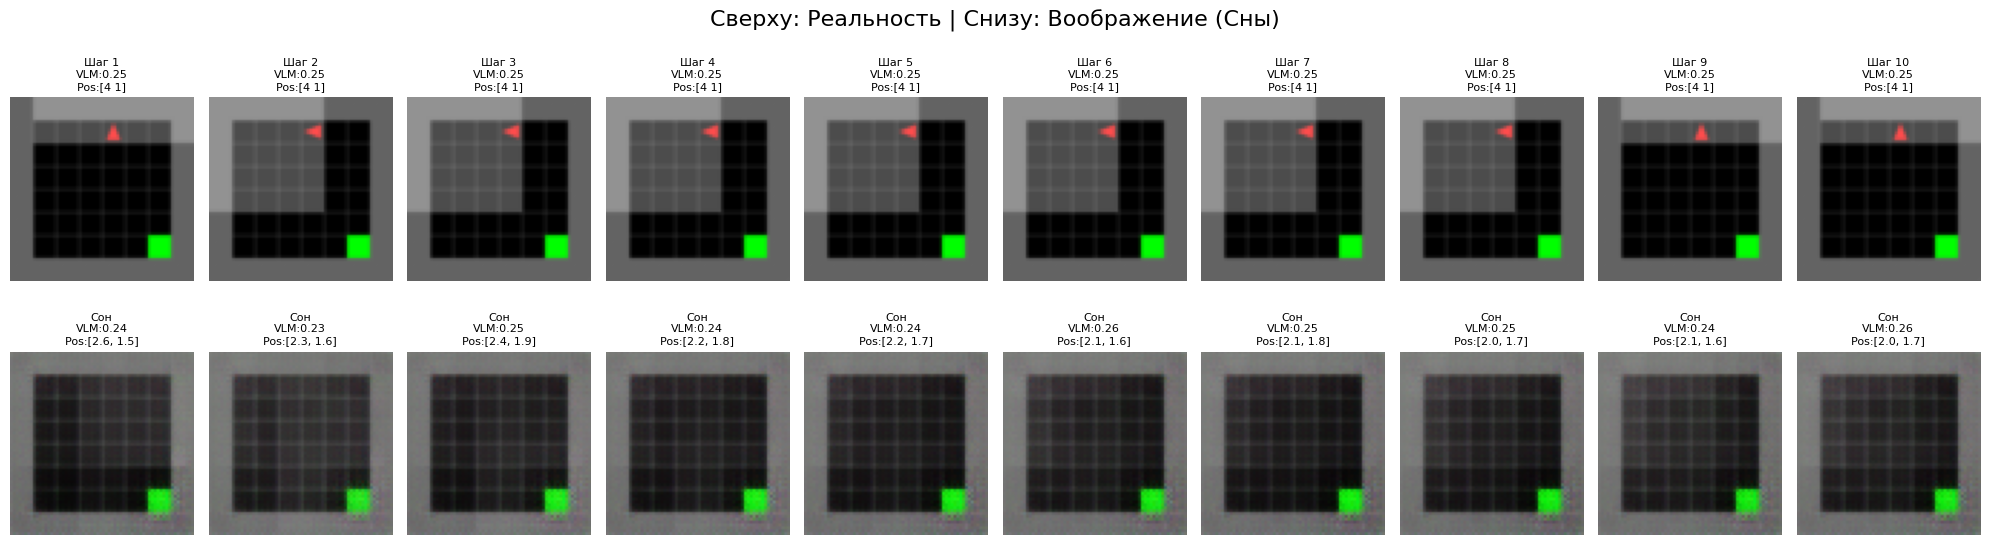

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Сэмплируем траекторию (теперь распаковываем 4 значения: добавился batch_pos)
batch_frames, batch_actions, batch_vlm_scores, batch_pos = replay_buffer.sample_batch(batch_size=1, seq_len=10)

batch_frames = batch_frames.to(device)        # [1, 11, 3, 64, 64]
batch_actions = batch_actions.to(device)      # [1, 10, Action_Dim]
batch_vlm_scores = batch_vlm_scores.to(device) # [1, 11, 1]
batch_pos = batch_pos.to(device)               # [1, 11, 2]

# 2. Инициализируем модель мира
h, z = rssm.init_state(batch_size=1, device=device)

# Первый шаг для контекста
embed = encoder(batch_frames[:, 0])
zero_action = torch.zeros_like(batch_actions[:, 0])
h, z, _ = rssm.observe_step(h, z, zero_action, embed)

imagined_frames = []
imagined_vlm_scores = []
imagined_pos = [] # Список для хранения координат из "сна"

# Автономный полет
# Создаем фиктивные skip-фичи для воображения, где нет реального изображения

with torch.no_grad():
    for t in range(10):
        h, z, _ = rssm.imagine_step(h, z, batch_actions[:, t])

        # Декодируем картинку
        pred_frame = decoder(h, z)
        imagined_frames.append(pred_frame.squeeze(0).cpu().permute(1, 2, 0).numpy())

        # VLM оценка
        pred_vlm = vlm_model(h, z)
        imagined_vlm_scores.append(pred_vlm.item())

        # Предсказание позиции через голову (умножаем на 6.0 для денормализации)
        pred_pos = pos_head(h)
        imagined_pos.append(pred_pos.squeeze(0).cpu().numpy() * 6.0)

# 3. Отрисовка
fig, axes = plt.subplots(2, 10, figsize=(20, 6))
fig.suptitle("Сверху: Реальность | Снизу: Воображение (Сны)", fontsize=16)

for i in range(10):
    # --- Реальность ---
    real_img = np.clip(batch_frames[0, i+1].cpu().permute(1, 2, 0).numpy(), 0.0, 1.0)
    real_p = batch_pos[0, i+1].cpu().numpy() # [x, y]

    axes[0, i].imshow(real_img)
    axes[0, i].set_title(f"Шаг {i+1}\nVLM:{batch_vlm_scores[0,i+1].item():.2f}\nPos:{real_p.astype(int)}", fontsize=8)
    axes[0, i].axis('off')

    # --- Сон ---
    imag_img = np.clip(imagined_frames[i], 0.0, 1.0)
    imag_p = imagined_pos[i]

    axes[1, i].imshow(imag_img)
    axes[1, i].set_title(f"Сон\nVLM:{imagined_vlm_scores[i]:.2f}\nPos:[{imag_p[0]:.1f}, {imag_p[1]:.1f}]", fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [17]:
def evaluate_agent(env, rssm, decoder, vlm_model, num_episodes=20, method='wm_vlm'):
    successes = 0
    total_returns = []

    for seed in range(num_episodes):
        obs = env.reset(seed=seed)
        done = False
        episode_return = 0

        while not done:
            # 1. Получаем латентное состояние (h, z) из энкодера
            # 2. MPC-планирование:
            if method == 'random':
                action = env.action_space.sample()
            else:
                # Генерируем 100 последовательностей действий
                # Прогоняем их через RSSM
                # Оцениваем через vlm_model (если method == 'wm_vlm')
                action = select_best_action_via_mpc(h, z, rssm, vlm_model, method)

            obs, reward, done, _ = env.step(action)
            episode_return += reward

        if episode_return > 0:
            successes += 1

    return successes / num_episodes

In [18]:
# # Возьми реальный кадр где агент у цели
# frame = env.render()
# frame_t = preprocess_frame(frame).unsqueeze(0).to(device)

# # Посмотри что энкодер вытащил
# embed = encoder(frame_t)  # [1, 256]
# print(embed.abs().mean(), embed.abs().max())
# # Если числа маленькие и похожие для разных позиций агента — энкодер не различает их
print(f"Min: {batch_frames.min().item()}, Max: {batch_frames.max().item()}")

Min: 0.0, Max: 1.0


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [ ]:
def compute_clip_score(frame_numpy, text_goal="agent at the green goal"):
    """
    frame_numpy: numpy array [256, 256, 3] из env.render()
    возвращает: float, косинусное сходство картинки и текста
    """
    # numpy → PIL → CLIP тензор
    pil_image = Image.fromarray(frame_numpy)
    image_tensor = clip_preprocess(pil_image).unsqueeze(0)  # [1, 3, 224, 224]

    # текст → тензор
    text_tensor = clip_tokenizer([text_goal])  # [1, 77]

    with torch.no_grad():
        image_features = clip_model.encode_image(image_tensor)   # [1, 512]
        text_features  = clip_model.encode_text(text_tensor)     # [1, 512]

        # нормализуем — cosine similarity это просто dot product нормализованных векторов
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features  = text_features  / text_features.norm(dim=-1, keepdim=True)

        score = (image_features @ text_features.T).item()  # скаляр от -1 до 1

    return score

In [ ]:
!pip install transformers qwen-vl-utils -q

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from PIL import Image

model_name = "Qwen/Qwen2-VL-2B-Instruct"
qwen_model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_name, torch_dtype=torch.float16
).to(device)
qwen_processor = AutoProcessor.from_pretrained(model_name)

def compute_qwen_score(frame_numpy: np.ndarray) -> float:
    pil_img = Image.fromarray(frame_numpy)
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": pil_img},
            {"type": "text", "text": (
                "This is a top-down grid world game. "
                "The red triangle is the agent. The green square is the goal. "
                "On a scale 0.0 to 1.0, how close is the agent to the green square? "
                "Reply with a single decimal number only."
            )}
        ]
    }]
    text = qwen_processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = qwen_processor(text=[text], images=[pil_img], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = qwen_model.generate(**inputs, max_new_tokens=10)

    answer = qwen_processor.decode(output_ids[0], skip_special_tokens=True)
    try:
        return float(answer.strip().split()[-1])
    except:
        return 0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 11.2 MB/s eta 0:00:00


config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

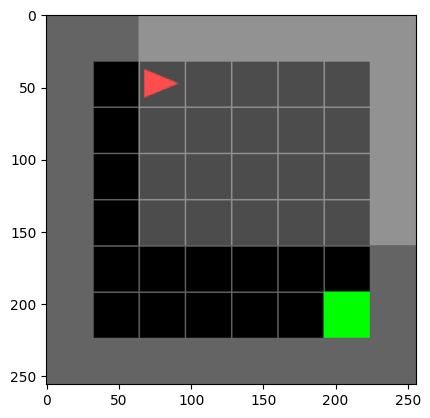

Близко к цели:  0.6000


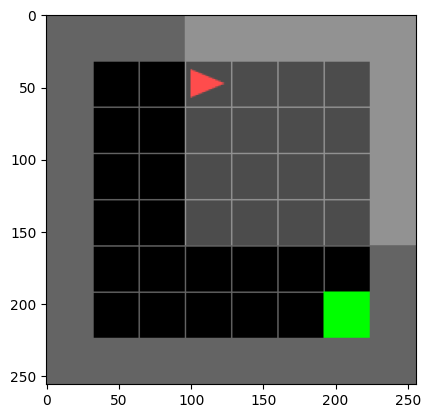

Близко к цели:  0.6000


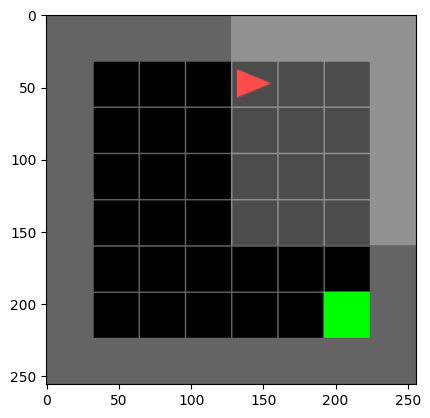

Близко к цели:  0.6000


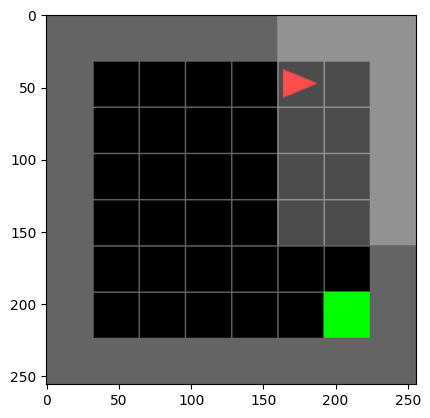

Близко к цели:  0.6000


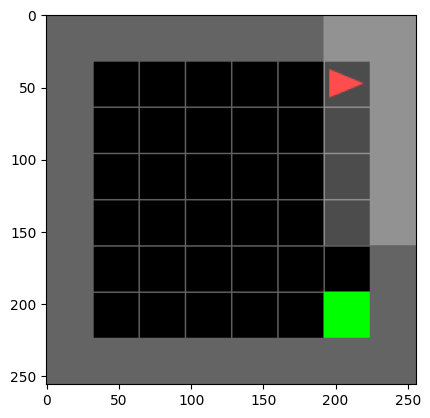

Близко к цели:  0.7000


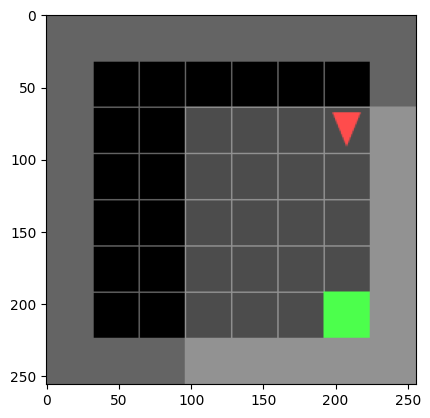

Близко к цели:  0.6000


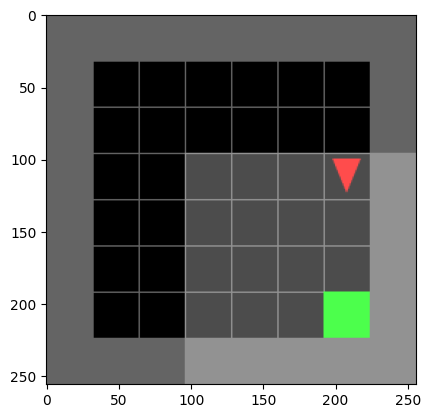

Близко к цели:  0.6000


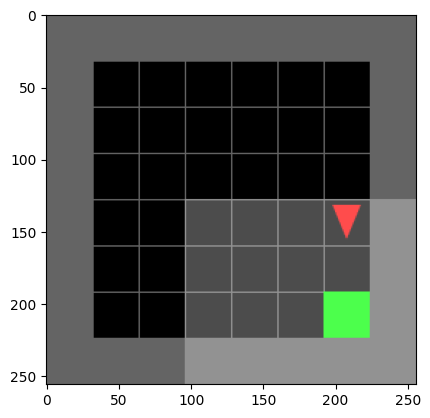

Близко к цели:  0.6000


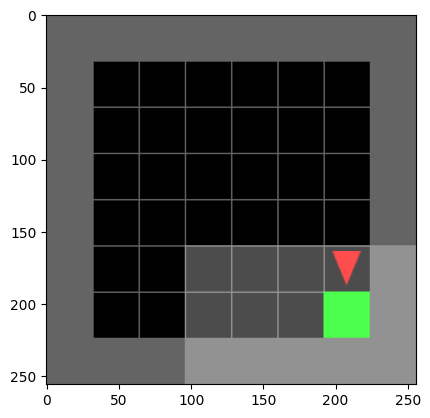

Близко к цели:  0.6000


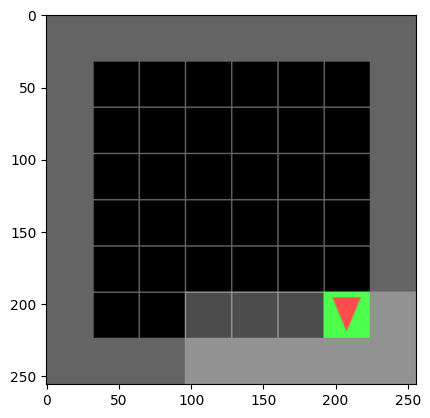

Близко к цели:  0.2000
Далеко от цели: 0.6000
Близко к цели:  0.2000


In [ ]:
# Кадр где агент далеко от цели
obs, _ = env.reset(seed=0)
frame_far = env.render()
score_far = compute_qwen_score(frame_far)

# Сделай несколько шагов к цели
for _ in range(5):
    env.step(2)  # вперёд
    frame_near = env.render()
    score_near = compute_qwen_score(frame_near)
    plt.imshow(frame_near)
    plt.show()
    print(f"Близко к цели:  {score_near:.4f}")
env.step(1)
for _ in range(5):
    env.step(2)  # вперёд
    frame_near = env.render()
    score_near = compute_qwen_score(frame_near)
    plt.imshow(frame_near)
    plt.show()
    print(f"Близко к цели:  {score_near:.4f}")

# frame_near = env.render()
# score_near = compute_clip_score(frame_near, "agent at the green goal")
print(f"Далеко от цели: {score_far:.4f}")
print(f"Близко к цели:  {score_near:.4f}")
# Если числа почти одинаковые — CLIP не видит разницы